In [1]:
# === Paso 1: Setup: imports, rutas, listar archivos ===
import os
import sys
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Para hacer 'from src import ...', Python necesita que el project root
# este en sys.path. Jupyter no lo agrega solo, asi que lo añadimos a mano.
# Truco: subimos desde CWD hasta encontrar un directorio que contenga 'src'.
# Asi funciona sin importar desde donde se haya lanzado el kernel.

def find_project_root(marker='src'):
    cwd = Path(os.getcwd()).resolve()
    for parent in [cwd, *cwd.parents]: # Va hacia atras hasta encontrar el root donde se encuentra el marker
        if (parent / marker).is_dir():
            return parent
    raise FileNotFoundError(
        f"No se encontro el project root con marcador '{marker}'. "
        f"Partiendo de: {cwd}"
    )

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

# importamos librerias locales de src
from src.readers.keithley_dean import list_measurements, read_curve, read_all_curves, view_measurements, get_dset_names, get_dset_array
from src.readers import print_structure
from src.plotting import plot_i_vs_time

data_folder = PROJECT_ROOT / 'data' / 'raw'

print(f"Project root: {PROJECT_ROOT}")
print(f"Data folder:   {data_folder}")
print("Archivos disponibles:")
for f in sorted(os.listdir(data_folder)):
    print(f"  {f}")

Project root: /home/dibarra/Documents/egofets-project
Data folder:   /home/dibarra/Documents/egofets-project/data/raw
Archivos disponibles:
  2026-06-26_test1.hdf5
  2026-06-29_test2.1.hdf5
  2026-06-29_test2.2.hdf5
  2026-06-29_test2.hdf5
  2026-06-30_test3.hdf5
  2026-07-08_test.hdf5
  2026-07-23 TMTES PS Phototransistor v3.hdf5
  notas.txt


In [2]:
# === Paso 2: Abrir HDF5 y listar SOLO los grupos top-level (mediciones) ===
# Cada grupo top-level es una medicion distinta (transfer, output, o stability)

hdf5_name = "2026-07-23 TMTES PS Phototransistor v3.hdf5"
hdf5_path = os.path.join(data_folder, hdf5_name)

def view_tree_content(file_path):
    with h5py.File(file_path, 'r') as f:

        print(f"📁 / (Raíz del árbol)")
        
        # 1. Definimos la función interna que procesará cada curva/dataset
        def mostrar_elemento(name, obj):
            level = name.count('/')
            sangria = '  ' * (level + 1) # +1 para dar espacio respecto a la raíz
            short_name = name.split('/')[-1]
                
            if isinstance(obj, h5py.Group):
                print(f"{sangria}📁 {short_name}/  Atributo: {obj.attrs.get("measurement_mode", 'desconocido')}")
            else:
                print(f"{sangria}⚡ {short_name} (Shape: {obj.shape}, Tipo: {obj.dtype}), Atributo: {obj.attrs.get("measurement_mode")}")
        
        # 2. Le pasamos esta función a visititems para que recorra el subgrupo
        f.visititems(mostrar_elemento)

view_tree_content(hdf5_path)

📁 / (Raíz del árbol)
  📁 TMTES PS OFET 1 light 545nm_00/  Atributo: desconocido
    ⚡ I_DS (Shape: (1027,), Tipo: float64), Atributo: None
    ⚡ I_GS (Shape: (1027,), Tipo: float64), Atributo: None
    ⚡ V_DS (Shape: (1027,), Tipo: float64), Atributo: None
    ⚡ V_GS (Shape: (1027,), Tipo: float64), Atributo: None
    ⚡ time (Shape: (1027,), Tipo: float64), Atributo: None
  📁 TMTES PS OFET 1 light 545nm_01/  Atributo: desconocido
    ⚡ I_DS (Shape: (2383,), Tipo: float64), Atributo: None
    ⚡ I_GS (Shape: (2383,), Tipo: float64), Atributo: None
    ⚡ V_DS (Shape: (2383,), Tipo: float64), Atributo: None
    ⚡ V_GS (Shape: (2383,), Tipo: float64), Atributo: None
    ⚡ time (Shape: (2383,), Tipo: float64), Atributo: None
  📁 TMTES PS OFET 1 light 545nm_02/  Atributo: desconocido
    ⚡ I_DS (Shape: (1360,), Tipo: float64), Atributo: None
    ⚡ I_GS (Shape: (1360,), Tipo: float64), Atributo: None
    ⚡ V_DS (Shape: (1360,), Tipo: float64), Atributo: None
    ⚡ V_GS (Shape: (1360,), Tipo: f

In [3]:
# obtener nombre de los dsets

measurment_name = "TMTES PS OFET light 370 nm_00"

get_dset_names(hdf5_path, measurment_name)

[{'name': 'I_DS', 'shape': (9147,), 'dtype': dtype('<f8'), 'attrs': {}},
 {'name': 'I_GS', 'shape': (9147,), 'dtype': dtype('<f8'), 'attrs': {}},
 {'name': 'V_DS', 'shape': (9147,), 'dtype': dtype('<f8'), 'attrs': {}},
 {'name': 'V_GS', 'shape': (9147,), 'dtype': dtype('<f8'), 'attrs': {}},
 {'name': 'time', 'shape': (9147,), 'dtype': dtype('<f8'), 'attrs': {}}]

In [4]:
i_ds, time = get_dset_array(hdf5_path, measurment_name, dsets=["I_DS", "time"])

data_dic = {
    "I_DS": i_ds,
    "Time": time
}

df = pd.DataFrame(data_dic)
print(df)

          I_DS        Time
0    -0.001563    0.000000
1    -0.001535    0.125203
2    -0.001525    0.166896
3    -0.001517    0.207948
4    -0.001509    0.243195
...        ...         ...
9142 -0.000711  379.858850
9143 -0.000711  379.903639
9144 -0.000711  379.945010
9145 -0.000711  379.986239
9146 -0.000711  380.027107

[9147 rows x 2 columns]


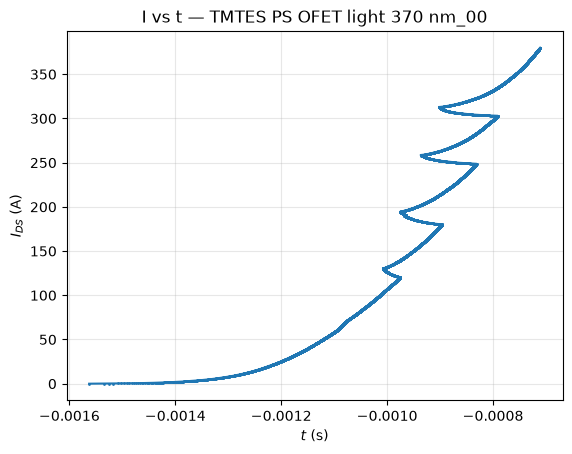

In [5]:
# graficamos

fig, ax = plt.subplots()

ax.plot(df["I_DS"], df["Time"], 'o-', ms=1)

ax.set_xlabel(r"$t$ (s)")
ax.set_ylabel(r"$I_{DS}$ (A)")
ax.set_title(f"I vs t — {measurment_name}")

ax.grid(True, alpha=0.3)